In [ ]:
# CELL 1 — mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [4]:
# CELL 2 — paths & (optional) local copy
import os, shutil
from pathlib import Path

DRIVE_BASE = "/content/drive/MyDrive/Colab Notebooks"
DRIVE_CHECKPOINT_DIR = os.path.join(DRIVE_BASE, "plant_checkpoints")
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)

# Where your original dataset lives in Drive (adjust if needed)
DRIVE_DATA_SRC = os.path.join(DRIVE_BASE, "plant_village_datatset/archive (7)/PlantVillage")

# Local fast copy path
LOCAL_DATA = "/content/PlantVillage"   # fast local working copy
SPLIT_LOCAL = "/content/PlantVillage_split"
SPLIT_DRIVE_COPY = os.path.join(DRIVE_BASE, "PlantVillage_split_backup")

# Copy dataset to /content if not already present (fast IO)
if not os.path.exists(LOCAL_DATA):
    print("Copying dataset to local disk (this may take a few minutes)...")
    shutil.copytree(DRIVE_DATA_SRC, LOCAL_DATA)
else:
    print("Local dataset already exists:", LOCAL_DATA)


Copying dataset to local disk (this may take a few minutes)...


KeyboardInterrupt: 

In [ ]:
# CELL 3 — create split if missing, then copy that split to Drive for backup
import random
from pathlib import Path

def create_split_local(src_root, out_root, train_frac=0.70, val_frac=0.15, test_frac=0.15, seed=42):
    src_root = Path(src_root); out_root = Path(out_root)
    random.seed(seed)
    for sp in ["train","val","test"]:
        (out_root/sp).mkdir(parents=True, exist_ok=True)
    classes = [d for d in src_root.iterdir() if d.is_dir()]
    print("Classes found:", len(classes))
    for cls in classes:
        files = [p for p in cls.glob("*") if p.is_file()]
        random.shuffle(files)
        n = len(files)
        t = int(train_frac * n); v = int(val_frac * n)
        groups = [files[:t], files[t:t+v], files[t+v:]]
        for sp, chunk in zip(["train","val","test"], groups):
            dest = out_root/sp/cls.name
            dest.mkdir(parents=True, exist_ok=True)
            for f in chunk:
                if not (dest/f.name).exists():
                    shutil.copy(f, dest/f.name)

# Create split locally if missing
if not Path(SPLIT_LOCAL).exists():
    print("Creating split at", SPLIT_LOCAL)
    create_split_local(LOCAL_DATA, SPLIT_LOCAL)
else:
    print("Split exists:", SPLIT_LOCAL)

# Backup split to Drive (safe copy)
print("Backing up split to Drive (will overwrite existing backup folder)...")
if os.path.exists(SPLIT_DRIVE_COPY):
    shutil.rmtree(SPLIT_DRIVE_COPY)
shutil.copytree(SPLIT_LOCAL, SPLIT_DRIVE_COPY)
print("Backup saved to Drive at:", SPLIT_DRIVE_COPY)


Split exists: /content/PlantVillage_split
Backing up split to Drive (will overwrite existing backup folder)...
Backup saved to Drive at: /content/drive/MyDrive/Colab Notebooks/PlantVillage_split_backup


In [6]:
import os

In [7]:
# CELL 4 — generators
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25, width_shift_range=0.15, height_shift_range=0.15,
    shear_range=0.1, zoom_range=0.15, horizontal_flip=True,
    brightness_range=(0.8,1.2), fill_mode='reflect'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(SPLIT_LOCAL, "train"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED
)
val_gen = val_datagen.flow_from_directory(
    os.path.join(SPLIT_LOCAL, "val"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_gen = val_datagen.flow_from_directory(
    os.path.join(SPLIT_LOCAL, "test"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)


Found 14441 images belonging to 15 classes.
Found 3089 images belonging to 15 classes.
Found 3108 images belonging to 15 classes.


In [10]:
# CELL 5 — model (MobileNetV2 feature-extract head)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base.trainable = False

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
out = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base.input, outputs=out)
model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,589,775 (9.88 MB)

 Trainable params: 331,791 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# CELL 6 — callbacks and autosave
import tensorflow as tf
import os
import shutil
from tensorflow.keras.callbacks import Callback, ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, CSVLogger

LOCAL_CHECKPOINT_DIR = "/content/output"
os.makedirs(LOCAL_CHECKPOINT_DIR, exist_ok=True)
LOCAL_BEST = os.path.join(LOCAL_CHECKPOINT_DIR, "mobilenet_best_local.h5")
DRIVE_BEST = os.path.join(DRIVE_CHECKPOINT_DIR, "mobilenet_best_drive.h5")
CSV_LOG_LOCAL = os.path.join(LOCAL_CHECKPOINT_DIR, "training_log.csv")
CSV_LOG_DRIVE = os.path.join(DRIVE_CHECKPOINT_DIR, "training_log.csv")

# Standard Keras callbacks
checkpoint_local = ModelCheckpoint(LOCAL_BEST, monitor='val_loss', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
csv_logger = CSVLogger(CSV_LOG_LOCAL)

# Custom callback: after each epoch copy local checkpoint & CSV to Drive (synchronous)
class CopyToDriveCallback(Callback):
    def __init__(self, local_ckpt, drive_ckpt, csv_local, csv_drive):
        super().__init__()
        self.local_ckpt = local_ckpt
        self.drive_ckpt = drive_ckpt
        self.csv_local = csv_local
        self.csv_drive = csv_drive

    def on_epoch_end(self, epoch, logs=None):
        # If local checkpoint exists, copy to Drive
        try:
            if os.path.exists(self.local_ckpt):
                shutil.copy(self.local_ckpt, self.drive_ckpt)
            if os.path.exists(self.csv_local):
                shutil.copy(self.csv_local, self.csv_drive)
            # optional: also save entire output folder snapshot (commented by default)
            # drive_snapshot = os.path.join(DRIVE_CHECKPOINT_DIR, f"output_snapshot_epoch_{epoch+1}")
            # if os.path.exists(LOCAL_CHECKPOINT_DIR):
            #     shutil.rmtree(drive_snapshot, ignore_errors=True)
            #     shutil.copytree(LOCAL_CHECKPOINT_DIR, drive_snapshot)
            print(f"[CopyToDrive] Epoch {epoch+1}: copied checkpoint/log to Drive.")
        except Exception as e:
            print("[CopyToDrive] Copy failed:", e)

copy_cb = CopyToDriveCallback(LOCAL_BEST, DRIVE_BEST, CSV_LOG_LOCAL, CSV_LOG_DRIVE)

# Use the callbacks list during training:
callbacks = [checkpoint_local, copy_cb, reduce_lr, early_stop, csv_logger]


In [ ]:
# CELL 8 — training (feature-extraction)
EPOCHS_FE = 10
history_fe = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FE,
    callbacks=callbacks,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6080 - loss: 1.2496
Epoch 1: val_loss improved from inf to 0.47800, saving model to /content/output/mobilenet_best_local.h5


[CopyToDrive] Epoch 1: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 1169s 3s/step - accuracy: 0.6082 - loss: 1.2488 - val_accuracy: 0.8310 - val_loss: 0.4780 - learning_rate: 0.0010
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8113 - loss: 0.5582
Epoch 2: val_loss improved from 0.47800 to 0.37404, saving model to /content/output/mobilenet_best_local.h5


[CopyToDrive] Epoch 2: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 1364s 3s/step - accuracy: 0.8114 - loss: 0.5582 - val_accuracy: 0.8721 - val_loss: 0.3740 - learning_rate: 0.0010
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8307 - loss: 0.4868
Epoch 3: val_loss did not improve from 0.37404
[CopyToDrive] Epoch 3: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 1159s 2s/step - accuracy: 0.8307 - loss: 0.4867 - val_accuracy: 0.8728 - val_loss: 0.3820 - learning_rate: 0.0010
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8537 - loss: 0.4327
Epoch 4: val_loss improved from 0.37404 to 0.30804, saving model to /content/output/mobilenet_best_local.h5


[CopyToDrive] Epoch 4: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 1089s 2s/step - accuracy: 0.8537 - loss: 0.4327 - val_accuracy: 0.8951 - val_loss: 0.3080 - learning_rate: 0.0010
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8596 - loss: 0.4142
Epoch 5: val_loss did not improve from 0.30804
[CopyToDrive] Epoch 5: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 1097s 2s/step - accuracy: 0.8596 - loss: 0.4142 - val_accuracy: 0.8796 - val_loss: 0.3293 - learning_rate: 0.0010
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8748 - loss: 0.3757
Epoch 6: val_loss did not improve from 0.30804
[CopyToDrive] Epoch 6: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 1052s 2s/step - accuracy: 0.8748 - loss: 0.3757 - val_accuracy: 0.8789 - val_loss: 0.3358 - learning_rate: 0.0010
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8811 - loss: 0.3505
Epoch 7: val_loss improved from 0.30804 to 0.28891, savin

[CopyToDrive] Epoch 7: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 1064s 2s/step - accuracy: 0.8811 - loss: 0.3505 - val_accuracy: 0.8961 - val_loss: 0.2889 - learning_rate: 0.0010
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8777 - loss: 0.3596
Epoch 8: val_loss did not improve from 0.28891
[CopyToDrive] Epoch 8: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 1102s 2s/step - accuracy: 0.8777 - loss: 0.3596 - val_accuracy: 0.8799 - val_loss: 0.3338 - learning_rate: 0.0010
Epoch 9/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8868 - loss: 0.3219
Epoch 9: val_loss did not improve from 0.28891
[CopyToDrive] Epoch 9: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 1085s 2s/step - accuracy: 0.8868 - loss: 0.3219 - val_accuracy: 0.8928 - val_loss: 0.3120 - learning_rate: 0.0010
Epoch 10/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8981 - loss: 0.3057
Epoch 10: val_loss improved from 0.28891 to 0.25908, sav

[CopyToDrive] Epoch 10: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 1088s 2s/step - accuracy: 0.8981 - loss: 0.3057 - val_accuracy: 0.9113 - val_loss: 0.2591 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.


In [ ]:
# --- Robust fix: locate base OR unfreeze all non-Input layers, then fine-tune ---
import os, shutil, tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, CSVLogger

# ensure Drive checkpoint dir exists
DRIVE_CHECKPOINT_DIR = "/content/drive/MyDrive/Colab Notebooks/plant_checkpoints"
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)

LOCAL_CHECKPOINT_DIR = "/content/output"
os.makedirs(LOCAL_CHECKPOINT_DIR, exist_ok=True)
LOCAL_FE_BEST = os.path.join(LOCAL_CHECKPOINT_DIR, "mobilenet_best_local.h5")
LOCAL_FT_BEST = os.path.join(LOCAL_CHECKPOINT_DIR, "mobilenet_finetune_best_local.h5")
DRIVE_FT_BEST = os.path.join(DRIVE_CHECKPOINT_DIR, "mobilenet_finetune_best_drive.h5")
CSV_LOG_LOCAL_FT = os.path.join(LOCAL_CHECKPOINT_DIR, "training_log_finetune.csv")
CSV_LOG_DRIVE_FT = os.path.join(DRIVE_CHECKPOINT_DIR, "training_log_finetune.csv")

# load feat-extract best weights if present
if os.path.exists(LOCAL_FE_BEST):
    print("Loading feature-extract best weights:", LOCAL_FE_BEST)
    try:
        model.load_weights(LOCAL_FE_BEST)
    except Exception as e:
        print("Warning: couldn't load FE weights:", e)
else:
    print("Feature-extract best checkpoint not found at", LOCAL_FE_BEST, "- proceeding with current model weights.")

# ----------------- Try to detect the nested base model -----------------
base = None

# 1) first: find an actual Model instance inside model.layers
for layer in model.layers:
    if isinstance(layer, tf.keras.Model):
        base = layer
        reason = "isinstance(layer, tf.keras.Model)"
        break

# 2) second: look for layers with 'mobilenet' in name (common naming)
if base is None:
    for layer in model.layers:
        if hasattr(layer, "name") and "mobilenet" in layer.name.lower():
            base = layer
            reason = "name contains 'mobilenet'"
            break

# 3) third: find a layer that itself has many sublayers
if base is None:
    for layer in model.layers:
        if hasattr(layer, "layers") and isinstance(layer.layers, list) and len(layer.layers) > 10:
            base = layer
            reason = "has many sublayers (>10)"
            break

if base is not None:
    print("Detected base model by:", reason, "->", getattr(base, "name", str(base)))
    total_base_layers = len(getattr(base, "layers", []))
    print("Total base layers detected:", total_base_layers)
else:
    print("Could not find nested base model automatically. Will unfreeze all non-Input layers (safe fallback).")

# --------------- unfreeze logic ---------------
n_unfreeze = 50  # your requested amount (used only if we found a base)
if base is not None and total_base_layers > 0:
    # safety clamp
    if n_unfreeze > total_base_layers:
        print(f"Requested {n_unfreeze} > {total_base_layers}. Unfreezing all {total_base_layers} base layers.")
        n_unfreeze = total_base_layers
    # freeze all base layers first
    for layer in base.layers:
        layer.trainable = False
    # unfreeze last n_unfreeze layers of the base
    for layer in base.layers[-n_unfreeze:]:
        layer.trainable = True
    print("Unfroze last", n_unfreeze, "layers of the detected base.")
else:
    # fallback: unfreeze every layer except InputLayer(s)
    cnt = 0
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.InputLayer):
            layer.trainable = False
        else:
            try:
                layer.trainable = True
                cnt += 1
            except Exception:
                pass
    print("Fallback: set trainable=True for", cnt, "layers (all non-Input layers).")

# Count trainable layers for logging
trainable_count = sum(1 for l in model.layers if getattr(l, "trainable", False))
print("Total top-level trainable layers in model:", trainable_count)

# --------------- recompile ---------------
fine_tune_lr = 1e-5
model.compile(optimizer=Adam(learning_rate=fine_tune_lr),
              loss='categorical_crossentropy', metrics=['accuracy'])
print("Model recompiled with lr =", fine_tune_lr)

# ---------------- callbacks -------------------
checkpoint_ft = ModelCheckpoint(LOCAL_FT_BEST, monitor='val_loss', save_best_only=True, verbose=1)
csv_logger_ft = CSVLogger(CSV_LOG_LOCAL_FT)
reduce_lr_ft = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
early_stop_ft = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)

class CopyToDriveCallback(tf.keras.callbacks.Callback):
    def __init__(self, local_ckpt, drive_ckpt, csv_local, csv_drive):
        super().__init__()
        self.local_ckpt = local_ckpt
        self.drive_ckpt = drive_ckpt
        self.csv_local = csv_local
        self.csv_drive = csv_drive
    def on_epoch_end(self, epoch, logs=None):
        try:
            if os.path.exists(self.local_ckpt):
                shutil.copy(self.local_ckpt, self.drive_ckpt)
            if os.path.exists(self.csv_local):
                shutil.copy(self.csv_local, self.csv_drive)
            print(f"[CopyToDrive-Finetune] Epoch {epoch+1}: copied checkpoint/log to Drive.")
        except Exception as e:
            print("[CopyToDrive-Finetune] Copy failed:", e)

copy_cb_ft = CopyToDriveCallback(LOCAL_FT_BEST, DRIVE_FT_BEST, CSV_LOG_LOCAL_FT, CSV_LOG_DRIVE_FT)
callbacks_ft = [checkpoint_ft, copy_cb_ft, reduce_lr_ft, early_stop_ft, csv_logger_ft]

Loading feature-extract best weights: /content/output/mobilenet_best_local.h5
Could not find nested base model automatically. Will unfreeze all non-Input layers (safe fallback).
Fallback: set trainable=True for 157 layers (all non-Input layers).
Total top-level trainable layers in model: 157
Model recompiled with lr = 1e-05


In [ ]:
# CELL A — rebuild FE model and load FE best weights
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import os

IMG_SIZE = (224,224)
LOCAL_CHECKPOINT_DIR = "/content/output"
LOCAL_FE_BEST = os.path.join(LOCAL_CHECKPOINT_DIR, "mobilenet_best_local.h5")

# Recreate the exact architecture used for feature-extraction
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base.trainable = False

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
out = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base.input, outputs=out)

# Compile (this compile is only to allow load + evaluate; will recompile later)
model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
print("Model built. Loading weights from:", LOCAL_FE_BEST)
model.load_weights(LOCAL_FE_BEST)
print("Weights loaded.")







Model built. Loading weights from: /content/output/mobilenet_best_local.h5
Weights loaded.


In [ ]:
# CELL B — unfreeze last N layers of the base model
n_unfreeze = 50   # change this if you want more/less (20, 50, 100 are common choices)

# ensure we have 'base' (the MobileNetV2 instance) — if not, try to find
try:
    base_model = base
except NameError:
    # try to locate nested base inside model
    import tensorflow as tf
    base_model = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model) and 'mobilenet' in layer.name.lower():
            base_model = layer
            break
    if base_model is None:
        # fallback: assume model.layers[1] is base (last resort)
        base_model = model.layers[1]
print("Detected base model:", getattr(base_model, "name", str(base_model)))
total_layers = len(getattr(base_model, "layers", []))
print("Total base layers:", total_layers)

if n_unfreeze > total_layers:
    print(f"Requested {n_unfreeze} > {total_layers}. Will unfreeze all base layers.")
    n_unfreeze = total_layers

# freeze whole base, then unfreeze last n_unfreeze
for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-n_unfreeze:]:
    layer.trainable = True

print(f"Unfroze last {n_unfreeze} layers of the base. Trainable base layers:",
      sum(1 for l in base_model.layers if getattr(l, "trainable", False)))



Detected base model: mobilenetv2_1.00_224
Total base layers: 154
Unfroze last 50 layers of the base. Trainable base layers: 50


In [ ]:
# CELL C — freeze BatchNorm layers (stabilize), recompile with low lr, and set callbacks
import tensorflow as tf, shutil
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, CSVLogger

# Freeze BatchNorm layers (recommended)
bn_count = 0
for layer in model.layers:
    if isinstance(layer, tf.keras.Model):
        for sub in layer.layers:
            if isinstance(sub, tf.keras.layers.BatchNormalization):
                sub.trainable = False
                bn_count += 1
    else:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
            bn_count += 1
print("BatchNorm layers frozen:", bn_count)

# Recompile with a low lr for fine-tuning
fine_tune_lr = 1e-5
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=fine_tune_lr),
              loss='categorical_crossentropy', metrics=['accuracy'])
print("Recompiled model with lr =", fine_tune_lr)

# Callbacks: local checkpoint and copy-to-Drive like before
DRIVE_CHECKPOINT_DIR = "/content/drive/MyDrive/Colab Notebooks/plant_checkpoints"
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)

LOCAL_FT_BEST = os.path.join(LOCAL_CHECKPOINT_DIR, "mobilenet_finetune_best_local.h5")
DRIVE_FT_BEST = os.path.join(DRIVE_CHECKPOINT_DIR, "mobilenet_finetune_best_drive.h5")
CSV_LOG_LOCAL_FT = os.path.join(LOCAL_CHECKPOINT_DIR, "training_log_finetune.csv")
CSV_LOG_DRIVE_FT = os.path.join(DRIVE_CHECKPOINT_DIR, "training_log_finetune.csv")

checkpoint_ft = ModelCheckpoint(LOCAL_FT_BEST, monitor='val_loss', save_best_only=True, verbose=1)
csv_logger_ft = CSVLogger(CSV_LOG_LOCAL_FT)
reduce_lr_ft = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
early_stop_ft = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)

class CopyToDriveCallback(tf.keras.callbacks.Callback):
    def __init__(self, local_ckpt, drive_ckpt, csv_local, csv_drive):
        super().__init__()
        self.local_ckpt = local_ckpt
        self.drive_ckpt = drive_ckpt
        self.csv_local = csv_local
        self.csv_drive = csv_drive
    def on_epoch_end(self, epoch, logs=None):
        try:
            if os.path.exists(self.local_ckpt):
                shutil.copy(self.local_ckpt, self.drive_ckpt)
            if os.path.exists(self.csv_local):
                shutil.copy(self.csv_local, self.csv_drive)
            print(f"[CopyToDrive-Finetune] Epoch {epoch+1}: copied checkpoint/log to Drive.")
        except Exception as e:
            print("[CopyToDrive-Finetune] Copy failed:", e)

copy_cb_ft = CopyToDriveCallback(LOCAL_FT_BEST, DRIVE_FT_BEST, CSV_LOG_LOCAL_FT, CSV_LOG_DRIVE_FT)
callbacks_ft = [checkpoint_ft, copy_cb_ft, reduce_lr_ft, early_stop_ft, csv_logger_ft]

print("Callbacks ready. Fine-tune checkpoint will be saved to:", LOCAL_FT_BEST)


BatchNorm layers frozen: 52
Recompiled model with lr = 1e-05
Callbacks ready. Fine-tune checkpoint will be saved to: /content/output/mobilenet_finetune_best_local.h5


In [ ]:
# CELL D — fine-tune (15 epochs)
EPOCHS_FT = 15
history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FT,
    callbacks=callbacks_ft,
    verbose=1
)


Epoch 1/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8972 - loss: 0.2974
Epoch 1: val_loss improved from inf to 0.21137, saving model to /content/output/mobilenet_finetune_best_local.h5


[CopyToDrive-Finetune] Epoch 1: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 1375s 3s/step - accuracy: 0.8972 - loss: 0.2974 - val_accuracy: 0.9298 - val_loss: 0.2114 - learning_rate: 1.0000e-05
Epoch 2/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9194 - loss: 0.2350
Epoch 2: val_loss improved from 0.21137 to 0.18423, saving model to /content/output/mobilenet_finetune_best_local.h5


[CopyToDrive-Finetune] Epoch 2: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 1340s 3s/step - accuracy: 0.9194 - loss: 0.2350 - val_accuracy: 0.9346 - val_loss: 0.1842 - learning_rate: 1.0000e-05
Epoch 3/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9251 - loss: 0.2165
Epoch 3: val_loss did not improve from 0.18423
[CopyToDrive-Finetune] Epoch 3: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 1337s 3s/step - accuracy: 0.9251 - loss: 0.2165 - val_accuracy: 0.9278 - val_loss: 0.2084 - learning_rate: 1.0000e-05
Epoch 4/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9362 - loss: 0.1865
Epoch 4: val_loss improved from 0.18423 to 0.16139, saving model to /content/output/mobilenet_finetune_best_local.h5


[CopyToDrive-Finetune] Epoch 4: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 1346s 3s/step - accuracy: 0.9362 - loss: 0.1865 - val_accuracy: 0.9443 - val_loss: 0.1614 - learning_rate: 1.0000e-05
Epoch 5/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9397 - loss: 0.1777
Epoch 5: val_loss did not improve from 0.16139
[CopyToDrive-Finetune] Epoch 5: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 1342s 3s/step - accuracy: 0.9397 - loss: 0.1776 - val_accuracy: 0.9262 - val_loss: 0.1958 - learning_rate: 1.0000e-05
Epoch 6/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9454 - loss: 0.1511
Epoch 6: val_loss did not improve from 0.16139
[CopyToDrive-Finetune] Epoch 6: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 1348s 3s/step - accuracy: 0.9454 - loss: 0.1511 - val_accuracy: 0.9200 - val_loss: 0.2338 - learning_rate: 1.0000e-05
Epoch 7/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9514 - loss: 0.1468
Epoch 7: val_loss 

[CopyToDrive-Finetune] Epoch 7: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 1331s 3s/step - accuracy: 0.9514 - loss: 0.1468 - val_accuracy: 0.9501 - val_loss: 0.1503 - learning_rate: 1.0000e-05
Epoch 8/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9563 - loss: 0.1333
Epoch 8: val_loss did not improve from 0.15026
[CopyToDrive-Finetune] Epoch 8: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 1341s 3s/step - accuracy: 0.9563 - loss: 0.1333 - val_accuracy: 0.9359 - val_loss: 0.1815 - learning_rate: 1.0000e-05
Epoch 9/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9566 - loss: 0.1240
Epoch 9: val_loss did not improve from 0.15026
[CopyToDrive-Finetune] Epoch 9: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 1356s 3s/step - accuracy: 0.9566 - loss: 0.1241 - val_accuracy: 0.9343 - val_loss: 0.2006 - learning_rate: 1.0000e-05
Epoch 10/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9584 - loss: 0.1195
Epoch 10: val_los

[CopyToDrive-Finetune] Epoch 11: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 1416s 3s/step - accuracy: 0.9627 - loss: 0.1022 - val_accuracy: 0.9482 - val_loss: 0.1496 - learning_rate: 5.0000e-06
Epoch 12/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9648 - loss: 0.1013

In [ ]:
# CELL 1
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, shutil
from pathlib import Path

DRIVE_BASE = "/content/drive/MyDrive/Colab Notebooks"
DRIVE_CHECKPOINT_DIR = os.path.join(DRIVE_BASE, "plant_checkpoints")
SPLIT_DRIVE_COPY = os.path.join(DRIVE_BASE, "PlantVillage_split_backup")

LOCAL_DATA = "/content/PlantVillage"            # local original dataset (fast copy)
SPLIT_LOCAL = "/content/PlantVillage_split"     # local split used by generators
LOCAL_CHECKPOINT_DIR = "/content/output"

os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOCAL_CHECKPOINT_DIR, exist_ok=True)

print("Drive checkpoint dir:", DRIVE_CHECKPOINT_DIR)
print("Drive split backup:", SPLIT_DRIVE_COPY)
print("Local split path:", SPLIT_LOCAL)


Mounted at /content/drive
Drive checkpoint dir: /content/drive/MyDrive/Colab Notebooks/plant_checkpoints
Drive split backup: /content/drive/MyDrive/Colab Notebooks/PlantVillage_split_backup
Local split path: /content/PlantVillage_split


In [ ]:
# CELL 2
import time

if not os.path.exists(SPLIT_LOCAL):
    if os.path.exists(SPLIT_DRIVE_COPY):
        print("Local split missing. Restoring split from Drive backup...")
        # copytree might fail on existing directories — use shutil.copytree
        try:
            shutil.copytree(SPLIT_DRIVE_COPY, SPLIT_LOCAL)
            print("Restored split to", SPLIT_LOCAL)
        except Exception as e:
            print("Copytree failed:", e)
            # try recursive copy fallback
            os.makedirs(SPLIT_LOCAL, exist_ok=True)
            for root, dirs, files in os.walk(SPLIT_DRIVE_COPY):
                rel = os.path.relpath(root, SPLIT_DRIVE_COPY)
                dest = os.path.join(SPLIT_LOCAL, rel)
                os.makedirs(dest, exist_ok=True)
                for f in files:
                    srcf = os.path.join(root, f)
                    dstf = os.path.join(dest, f)
                    if not os.path.exists(dstf):
                        shutil.copy2(srcf, dstf)
            print("Fallback restore done.")
    else:
        raise FileNotFoundError(f"No split backup found at {SPLIT_DRIVE_COPY}. If your dataset only existed locally, you'll need to re-copy it from its original Drive location.")
else:
    print("Local split already exists:", SPLIT_LOCAL)



Local split missing. Restoring split from Drive backup...
Restored split to /content/PlantVillage_split


In [ ]:
# CELL 3
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25, width_shift_range=0.15, height_shift_range=0.15,
    shear_range=0.1, zoom_range=0.15, horizontal_flip=True,
    brightness_range=(0.8,1.2), fill_mode='reflect'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(SPLIT_LOCAL, "train"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED
)
val_gen = val_datagen.flow_from_directory(
    os.path.join(SPLIT_LOCAL, "val"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_gen = val_datagen.flow_from_directory(
    os.path.join(SPLIT_LOCAL, "test"),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
print("Generators recreated. Num classes:", train_gen.num_classes)


Found 14441 images belonging to 15 classes.
Found 3089 images belonging to 15 classes.
Found 3108 images belonging to 15 classes.
Generators recreated. Num classes: 15


In [ ]:
# CELL 4
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

IMG_SIZE = (224,224)

# Build exact FE architecture used previously
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base.trainable = False

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
out = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base.input, outputs=out)
# compile with a safe lr, will recompile before fine-tuning
model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

# Try to load fine-tune best first, then FE best
FT_DRIVE = os.path.join(DRIVE_CHECKPOINT_DIR, "mobilenet_finetune_best_drive.h5")
FE_DRIVE = os.path.join(DRIVE_CHECKPOINT_DIR, "mobilenet_best_drive.h5")
LOCAL_FT = os.path.join(LOCAL_CHECKPOINT_DIR, "mobilenet_finetune_best_local.h5")
LOCAL_FE = os.path.join(LOCAL_CHECKPOINT_DIR, "mobilenet_best_local.h5")

loaded_from = None
for candidate in [LOCAL_FT, FT_DRIVE, LOCAL_FE, FE_DRIVE]:
    if os.path.exists(candidate):
        try:
            model.load_weights(candidate)
            loaded_from = candidate
            print("Loaded weights from:", candidate)
            break
        except Exception as e:
            print("Failed to load weights from", candidate, ":", e)

if loaded_from is None:
    print("No checkpoint found to load. Training will start from imagenet-initialized head (not ideal).")
else:
    # quick eval to confirm baseline val acc is close to before
    loss, acc = model.evaluate(val_gen, verbose=1)
    print("Baseline after loading -> VAL loss, VAL acc:", loss, acc)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Loaded weights from: /content/drive/MyDrive/Colab Notebooks/plant_checkpoints/mobilenet_finetune_best_drive.h5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


97/97 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.9657 - loss: 0.0972
Baseline after loading -> VAL loss, VAL acc: 0.1388346403837204 0.9553253650665283


In [ ]:
# CELL 5
import csv

# Path to CSV log saved in Drive (from earlier copy-to-drive)
CSV_LOG_DRIVE = os.path.join(DRIVE_CHECKPOINT_DIR, "training_log_finetune.csv")
CSV_LOG_LOCAL = os.path.join(LOCAL_CHECKPOINT_DIR, "training_log_finetune.csv")

# prefer Drive CSV if exists, else local
csv_path = CSV_LOG_DRIVE if os.path.exists(CSV_LOG_DRIVE) else (CSV_LOG_LOCAL if os.path.exists(CSV_LOG_LOCAL) else None)
last_epoch_completed = 0

if csv_path:
    print("Found CSV log at:", csv_path)
    # Read last non-header line to count epochs (CSVLogger writes one row per epoch)
    with open(csv_path, 'r') as f:
        lines = f.read().strip().splitlines()
    if len(lines) <= 1:
        last_epoch_completed = 0
    else:
        # CSVLogger writes header + rows; epochs are sequential starting at 0 or 1 depending on implementation.
        # We'll infer last epoch number by counting rows-1
        last_epoch_completed = len(lines) - 1
    print("Inferred completed epochs from CSV:", last_epoch_completed)
else:
    print("No CSV log found. Assuming 0 epochs completed.")
    last_epoch_completed = 0

# User-set total fine-tune epochs you intended (e.g., 15)
TOTAL_FINE_TUNE_EPOCHS = 15
remaining_epochs = max(0, TOTAL_FINE_TUNE_EPOCHS - last_epoch_completed)
print("Total intended FT epochs:", TOTAL_FINE_TUNE_EPOCHS)
print("Remaining epochs to run:", remaining_epochs)

# Set initial_epoch for model.fit below
initial_epoch = last_epoch_completed


Found CSV log at: /content/drive/MyDrive/Colab Notebooks/plant_checkpoints/training_log_finetune.csv
Inferred completed epochs from CSV: 11
Total intended FT epochs: 15
Remaining epochs to run: 4


In [ ]:
# CELL 6
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, CSVLogger

# Paths
LOCAL_FT_BEST = os.path.join(LOCAL_CHECKPOINT_DIR, "mobilenet_finetune_best_local.h5")
DRIVE_FT_BEST = os.path.join(DRIVE_CHECKPOINT_DIR, "mobilenet_finetune_best_drive.h5")
CSV_LOG_LOCAL_FT = os.path.join(LOCAL_CHECKPOINT_DIR, "training_log_finetune.csv")
CSV_LOG_DRIVE_FT = os.path.join(DRIVE_CHECKPOINT_DIR, "training_log_finetune.csv")

# Callbacks
checkpoint_ft = ModelCheckpoint(LOCAL_FT_BEST, monitor='val_loss', save_best_only=True, verbose=1)
# CSVLogger in append mode so we continue the same log
csv_logger_ft = CSVLogger(CSV_LOG_LOCAL_FT, append=True)

reduce_lr_ft = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
early_stop_ft = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)

class CopyToDriveCallback(tf.keras.callbacks.Callback):
    def __init__(self, local_ckpt, drive_ckpt, csv_local, csv_drive):
        super().__init__()
        self.local_ckpt = local_ckpt
        self.drive_ckpt = drive_ckpt
        self.csv_local = csv_local
        self.csv_drive = csv_drive
    def on_epoch_end(self, epoch, logs=None):
        try:
            if os.path.exists(self.local_ckpt):
                shutil.copy(self.local_ckpt, self.drive_ckpt)
            if os.path.exists(self.csv_local):
                shutil.copy(self.csv_local, self.csv_drive)
            print(f"[CopyToDrive] Epoch {epoch+1}: copied checkpoint/log to Drive.")
        except Exception as e:
            print("[CopyToDrive] Copy failed:", e)

copy_cb = CopyToDriveCallback(LOCAL_FT_BEST, DRIVE_FT_BEST, CSV_LOG_LOCAL_FT, CSV_LOG_DRIVE_FT)

callbacks = [checkpoint_ft, csv_logger_ft, copy_cb, reduce_lr_ft, early_stop_ft]
print("Callbacks prepared. CSVLogger append:", True)


Callbacks prepared. CSVLogger append: True


In [ ]:
# CELL 7
# Freeze BatchNorm layers for stable fine-tuning
bn_count = 0
for layer in model.layers:
    if isinstance(layer, tf.keras.Model):
        for sub in layer.layers:
            if isinstance(sub, tf.keras.layers.BatchNormalization):
                sub.trainable = False
                bn_count += 1
    else:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
            bn_count += 1
print("BatchNorm layers frozen:", bn_count)

from tensorflow.keras.optimizers import Adam
fine_tune_lr = 1e-5
model.compile(optimizer=Adam(learning_rate=fine_tune_lr), loss='categorical_crossentropy', metrics=['accuracy'])
print("Recompiled with lr =", fine_tune_lr)


BatchNorm layers frozen: 52
Recompiled with lr = 1e-05


In [ ]:
# CELL 8 — resume fit
if remaining_epochs <= 0:
    print("No remaining epochs to run. You have already finished the intended fine-tune epochs.")
else:
    print(f"Resuming fine-tune from initial_epoch={initial_epoch} for {remaining_epochs} more epochs...")
    history_resume = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=initial_epoch + remaining_epochs,
        initial_epoch=initial_epoch,
        callbacks=callbacks,
        verbose=1
    )
    print("Resumed fine-tuning complete (or stopped by callbacks).")


Resuming fine-tune from initial_epoch=11 for 4 more epochs...
Epoch 12/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9721 - loss: 0.0836
Epoch 12: val_loss improved from inf to 0.13389, saving model to /content/output/mobilenet_finetune_best_local.h5


[CopyToDrive] Epoch 12: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 918s 2s/step - accuracy: 0.9721 - loss: 0.0836 - val_accuracy: 0.9579 - val_loss: 0.1339 - learning_rate: 1.0000e-05
Epoch 13/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9742 - loss: 0.0800
Epoch 13: val_loss did not improve from 0.13389
[CopyToDrive] Epoch 13: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 918s 2s/step - accuracy: 0.9743 - loss: 0.0800 - val_accuracy: 0.9563 - val_loss: 0.1343 - learning_rate: 1.0000e-05
Epoch 14/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9747 - loss: 0.0745
Epoch 14: val_loss did not improve from 0.13389
[CopyToDrive] Epoch 14: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 921s 2s/step - accuracy: 0.9747 - loss: 0.0745 - val_accuracy: 0.9566 - val_loss: 0.1349 - learning_rate: 1.0000e-05
Epoch 15/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9734 - loss: 0.0803
Epoch 15: val_loss improved from 0.13389

[CopyToDrive] Epoch 15: copied checkpoint/log to Drive.
452/452 ━━━━━━━━━━━━━━━━━━━━ 903s 2s/step - accuracy: 0.9734 - loss: 0.0803 - val_accuracy: 0.9566 - val_loss: 0.1322 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 15.
Resumed fine-tuning complete (or stopped by callbacks).


In [10]:
# CELL 9
print("Evaluating validation set...")
print(model.evaluate(val_gen, verbose=1))
print("Evaluating test set...")
print(model.evaluate(test_gen, verbose=1))


Evaluating validation set...
97/97 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.9656 - loss: 0.0946
[0.1322295218706131, 0.9566202759742737]
Evaluating test set...
98/98 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.9713 - loss: 0.0932
[0.12591035664081573, 0.9607464671134949]


Loading existing predictions from /content/output/test_predictions.csv
Computing probabilities with model.predict (fallback)...
98/98 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step

Overall test accuracy (top-1): 0.9607
Top-3 accuracy: 0.9971

CLASSIFICATION REPORT:

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot     0.9934    1.0000    0.9967       151
                     Pepper__bell___healthy     1.0000    0.9955    0.9978       223
                      Potato___Early_blight     0.9868    0.9933    0.9900       150
                       Potato___Late_blight     0.9800    0.9800    0.9800       150
                           Potato___healthy     0.9200    0.9583    0.9388        24
                      Tomato_Bacterial_spot     0.9844    0.9844    0.9844       320
                        Tomato_Early_blight     0.9531    0.8133    0.8777       150
                         Tomato_Late_blight     0.9721    0.9721

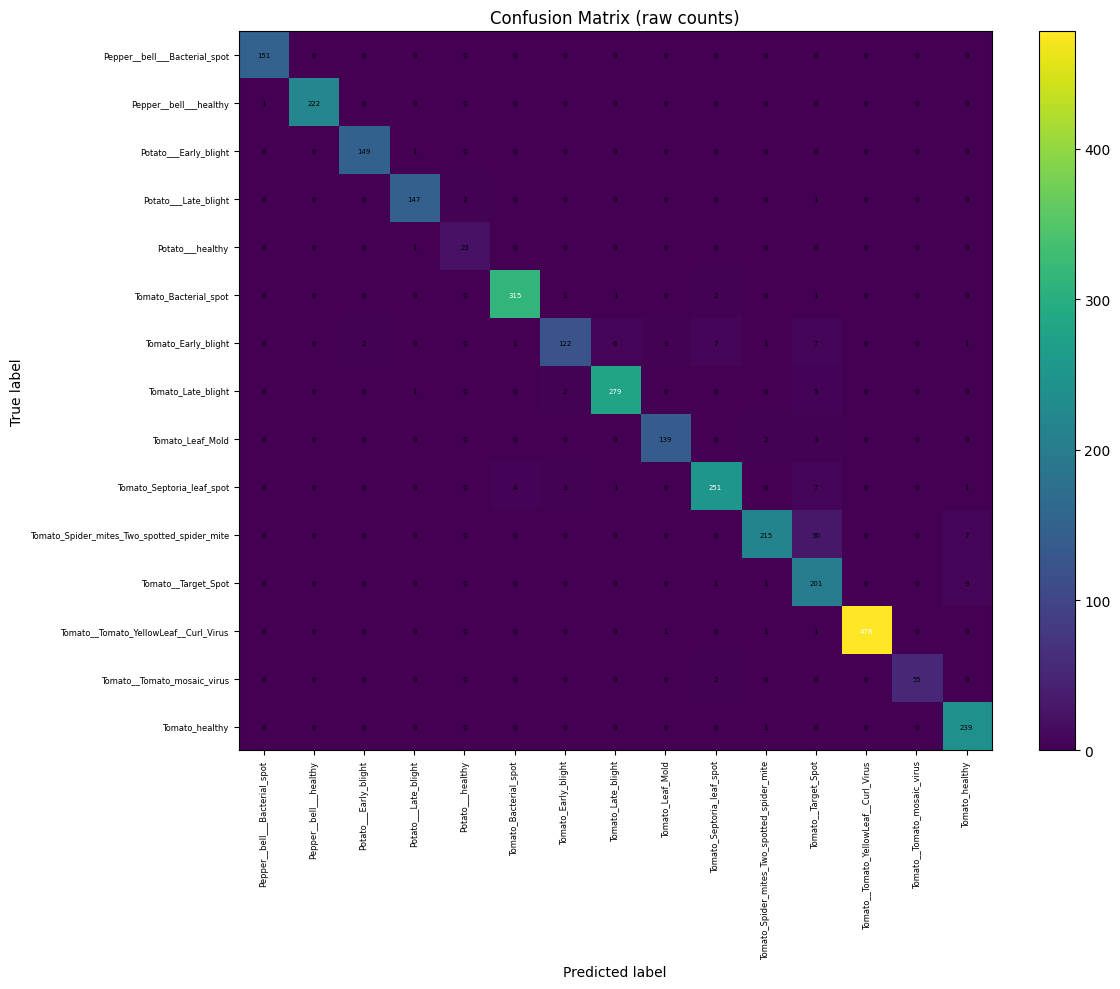

Saved /content/output/confusion_matrix_raw.png


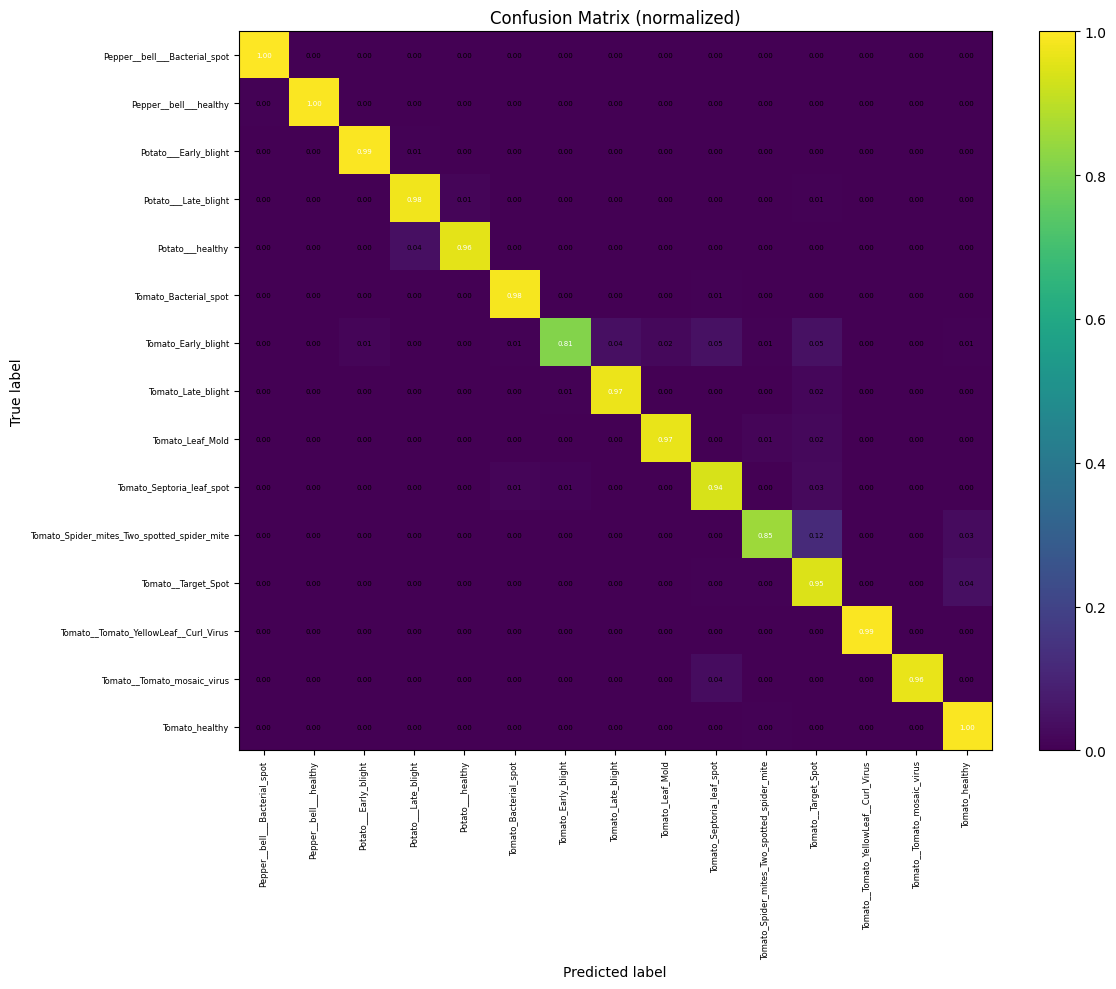

Saved /content/output/confusion_matrix_normalized.png
Saved classification_report.txt and per_class_metrics.csv
Copied to Drive: /content/drive/MyDrive/Colab Notebooks/plant_checkpoints/confusion_matrix_raw.png
Copied to Drive: /content/drive/MyDrive/Colab Notebooks/plant_checkpoints/confusion_matrix_normalized.png
Copied to Drive: /content/drive/MyDrive/Colab Notebooks/plant_checkpoints/classification_report.txt
Copied to Drive: /content/drive/MyDrive/Colab Notebooks/plant_checkpoints/per_class_metrics.csv
Copied to Drive: /content/drive/MyDrive/Colab Notebooks/plant_checkpoints/test_predictions.csv


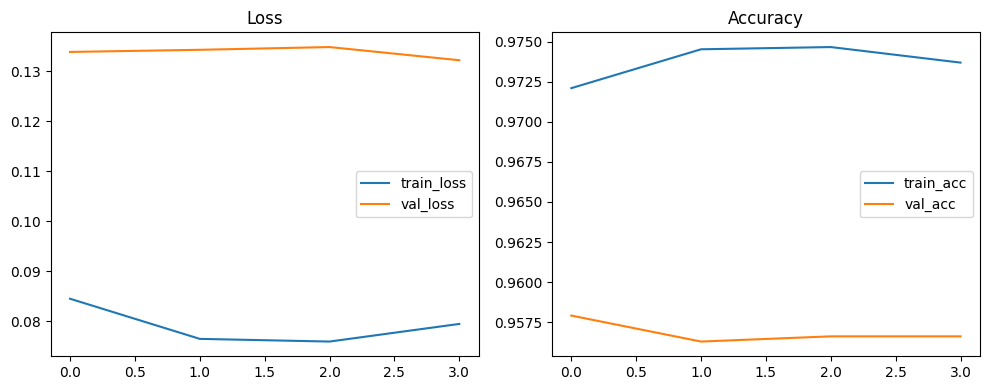

Saved training curves to /content/output/training_curves.png

Evaluation complete. Key artifacts are in: /content/output and copies in: /content/drive/MyDrive/Colab Notebooks/plant_checkpoints


In [12]:
# ----------------- DETAILED EVALUATION CELL -----------------
import os, sys, numpy as np, pandas as pd, matplotlib.pyplot as plt, itertools, shutil
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score, top_k_accuracy_score
import tensorflow as tf

LOCAL_OUT = "/content/output"
DRIVE_OUT = "/content/drive/MyDrive/Colab Notebooks/plant_checkpoints"
os.makedirs(LOCAL_OUT, exist_ok=True)
os.makedirs(DRIVE_OUT, exist_ok=True)

# ---- 1) Load predictions (prefer CSV if exists) ----
csv_path = os.path.join(LOCAL_OUT, "test_predictions.csv")
if os.path.exists(csv_path):
    print("Loading existing predictions from", csv_path)
    df = pd.read_csv(csv_path)
    # Expect columns: filepath, true_label, pred_label, pred_prob or probs
    # If probs column not present, we'll re-run model.predict below for probabilities.
    labels = sorted(list({*df['true_label'].unique(), *df['pred_label'].unique()}))
    y_true_str = df['true_label'].tolist()
    y_pred_str = df['pred_label'].tolist()
    # Map label names to indices
    label_to_idx = {lab:i for i, lab in enumerate(labels)}
    y_true = np.array([label_to_idx[s] for s in y_true_str])
    y_pred = np.array([label_to_idx[s] for s in y_pred_str])
    probs_available = 'probs' in df.columns or 'pred_prob' in df.columns
    preds_probs = None
else:
    print("Predictions CSV not found. Running model.predict on test_gen (this may take a while)...")
    preds_probs = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(preds_probs, axis=1)
    y_true = test_gen.classes
    labels = list(test_gen.class_indices.keys())

# ---- 2) If we loaded CSV but need probs for top-k, try to compute them ----
if 'preds_probs' not in locals() or preds_probs is None:
    # try to recreate preds_probs from CSV 'probs' column if present
    if os.path.exists(csv_path):
        if 'probs' in df.columns:
            try:
                preds_probs = np.vstack(df['probs'].apply(lambda s: np.fromstring(s.strip('[]'), sep=', ')))
                print("Reconstructed probs from CSV.")
            except Exception:
                preds_probs = None
        else:
            preds_probs = None

    # else compute from model (slow but reliable)
    if preds_probs is None:
        print("Computing probabilities with model.predict (fallback)...")
        preds_probs = model.predict(test_gen, verbose=1)
        y_pred = np.argmax(preds_probs, axis=1)
        y_true = test_gen.classes
        labels = list(test_gen.class_indices.keys())

# ---- 3) Basic overall metrics ----
acc = accuracy_score(y_true, y_pred)
print(f"\nOverall test accuracy (top-1): {acc:.4f}")

# top-3 if classes >=3
top3 = None
if preds_probs is not None and preds_probs.shape[1] >= 3:
    try:
        top3 = top_k_accuracy_score(y_true, preds_probs, k=3)
        print(f"Top-3 accuracy: {top3:.4f}")
    except Exception as e:
        print("Top-3 calc failed:", e)

# ---- 4) Classification report & macro/micro averages ----
target_names = labels
report = classification_report(y_true, y_pred, target_names=target_names, digits=4)
print("\nCLASSIFICATION REPORT:\n")
print(report)

# Detailed precision/recall/f1 arrays
p, r, f1, sup = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
per_class_df = pd.DataFrame({
    'label': target_names,
    'precision': p,
    'recall': r,
    'f1': f1,
    'support': sup
}).sort_values('support', ascending=False)
print("\nPer-class summary (top rows):")
print(per_class_df.head(10))

# ---- 5) Confusion matrix (raw and normalized) ----
cm = confusion_matrix(y_true, y_pred)
with np.errstate(all='ignore'):
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None]
cm_norm = np.nan_to_num(cm_norm)

def plot_and_save_cm(mat, title, out_path, fmt='d', dpi=150):
    plt.figure(figsize=(12,10))
    plt.imshow(mat, interpolation='nearest', cmap='viridis', aspect='auto')
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(target_names))
    plt.xticks(ticks, target_names, rotation=90, fontsize=6)
    plt.yticks(ticks, target_names, fontsize=6)
    thresh = mat.max()/2.
    for i,j in itertools.product(range(mat.shape[0]), range(mat.shape[1])):
        val = mat[i,j]
        s = format(int(val) if fmt=='d' else float(val), fmt)
        plt.text(j, i, s, ha='center', va='center', color='white' if val>thresh else 'black', fontsize=5)
    plt.ylabel('True label'); plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches='tight', dpi=dpi)
    plt.show()
    print("Saved", out_path)

raw_cm_path = os.path.join(LOCAL_OUT, "confusion_matrix_raw.png")
norm_cm_path = os.path.join(LOCAL_OUT, "confusion_matrix_normalized.png")
plot_and_save_cm(cm, "Confusion Matrix (raw counts)", raw_cm_path, fmt='d')
plot_and_save_cm(cm_norm, "Confusion Matrix (normalized)", norm_cm_path, fmt='.2f')

# ---- 6) Save classification report and per-class df to files ----
with open(os.path.join(LOCAL_OUT, "classification_report.txt"), "w") as f:
    f.write(report)
per_class_df.to_csv(os.path.join(LOCAL_OUT, "per_class_metrics.csv"), index=False)
print("Saved classification_report.txt and per_class_metrics.csv")

# ---- 7) Copy artifacts to Drive ----
artifacts = [raw_cm_path, norm_cm_path, os.path.join(LOCAL_OUT, "classification_report.txt"), os.path.join(LOCAL_OUT, "per_class_metrics.csv"), csv_path if os.path.exists(csv_path) else None]
for a in artifacts:
    if a and os.path.exists(a):
        try:
            shutil.copy(a, DRIVE_OUT)
            print("Copied to Drive:", os.path.join(DRIVE_OUT, os.path.basename(a)))
        except Exception as e:
            print("Drive copy failed for", a, ":", e)

# ---- 8) If history is available, plot training curves; else try to load CSV log to reconstruct ----
if 'history_ft' in globals():
    hist = history_ft.history
elif 'history_resume' in globals():
    hist = history_resume.history
else:
    hist = None

if hist is None:
    # try to read CSV training log to plot val/train curves
    csv_log = os.path.join(LOCAL_OUT, "training_log_finetune.csv")
    if not os.path.exists(csv_log):
        csv_log = os.path.join(DRIVE_OUT, "training_log_finetune.csv")
    if os.path.exists(csv_log):
        try:
            df_log = pd.read_csv(csv_log)
            # CSVLogger may have epoch,loss,accuracy,val_loss,val_accuracy
            plt.figure(figsize=(10,4))
            if 'loss' in df_log.columns and 'val_loss' in df_log.columns:
                plt.subplot(1,2,1)
                plt.plot(df_log['loss'], label='train_loss')
                plt.plot(df_log['val_loss'], label='val_loss')
                plt.legend(); plt.title('Loss')
            if 'accuracy' in df_log.columns and 'val_accuracy' in df_log.columns:
                plt.subplot(1,2,2)
                plt.plot(df_log['accuracy'], label='train_acc')
                plt.plot(df_log['val_accuracy'], label='val_acc')
                plt.legend(); plt.title('Accuracy')
            plt.tight_layout()
            curves_path = os.path.join(LOCAL_OUT, "training_curves_from_csv.png")
            plt.savefig(curves_path, bbox_inches='tight', dpi=150)
            plt.show()
            print("Saved training curves (from CSV) to", curves_path)
            # copy
            try:
                shutil.copy(curves_path, DRIVE_OUT)
            except: pass
        except Exception as e:
            print("Could not plot from CSV log:", e)
    else:
        print("No history object or CSV log found. Skipping training curves.")
else:
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(hist.get('loss',[]), label='train_loss')
    plt.plot(hist.get('val_loss',[]), label='val_loss')
    plt.legend(); plt.title('Loss')
    plt.subplot(1,2,2)
    plt.plot(hist.get('accuracy',[]), label='train_acc')
    plt.plot(hist.get('val_accuracy',[]), label='val_acc')
    plt.legend(); plt.title('Accuracy')
    plt.tight_layout()
    curves_path = os.path.join(LOCAL_OUT, "training_curves.png")
    plt.savefig(curves_path, bbox_inches='tight', dpi=150)
    plt.show()
    try:
        shutil.copy(curves_path, DRIVE_OUT)
    except: pass
    print("Saved training curves to", curves_path)

print("\nEvaluation complete. Key artifacts are in:", LOCAL_OUT, "and copies in:", DRIVE_OUT)


Detected classes: 15
Selected 15 indices (one per class).
Using last conv layer: Conv_1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


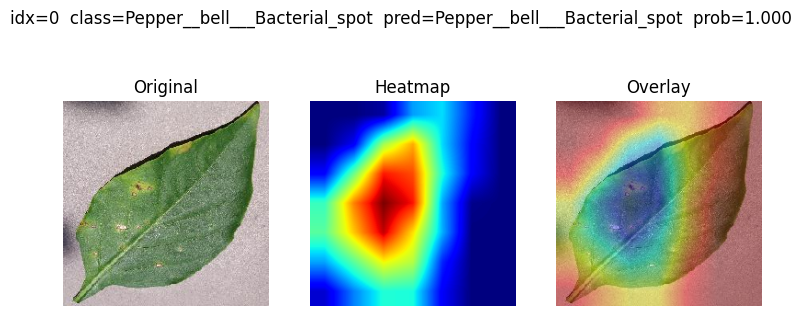

Saved: /content/output/gradcam/gradcam_idx0_Pepper__bell___Bacterial_spot_heat.png and /content/output/gradcam/gradcam_idx0_Pepper__bell___Bacterial_spot_overlay.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step


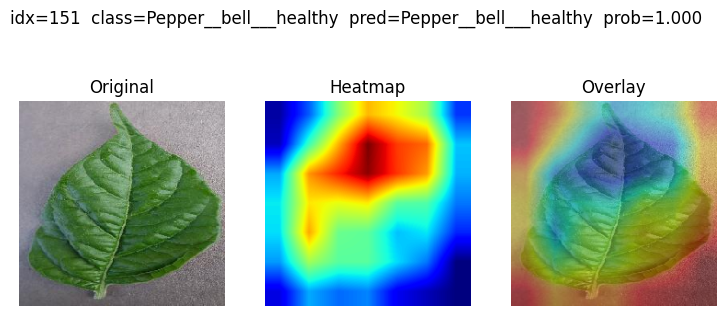

Saved: /content/output/gradcam/gradcam_idx151_Pepper__bell___healthy_heat.png and /content/output/gradcam/gradcam_idx151_Pepper__bell___healthy_overlay.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step


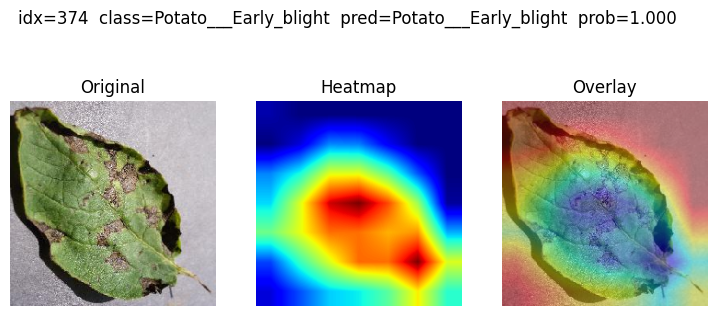

Saved: /content/output/gradcam/gradcam_idx374_Potato___Early_blight_heat.png and /content/output/gradcam/gradcam_idx374_Potato___Early_blight_overlay.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step


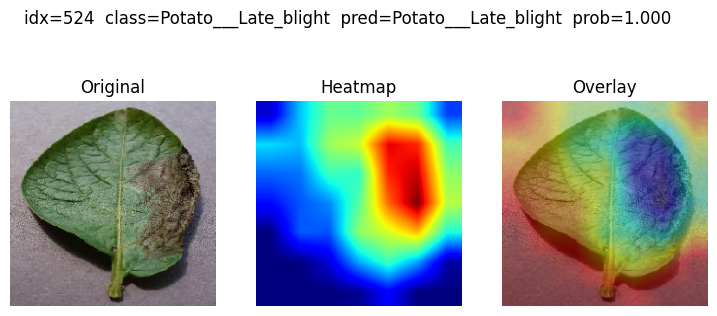

Saved: /content/output/gradcam/gradcam_idx524_Potato___Late_blight_heat.png and /content/output/gradcam/gradcam_idx524_Potato___Late_blight_overlay.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


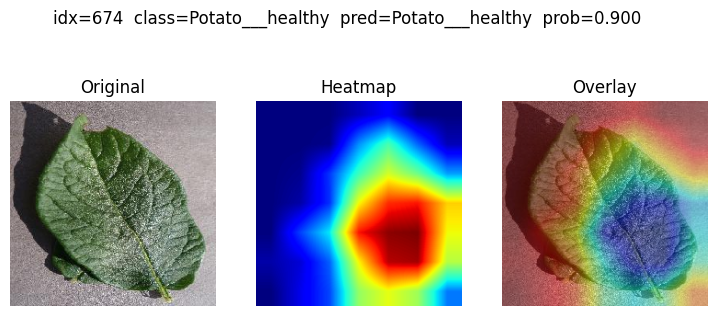

Saved: /content/output/gradcam/gradcam_idx674_Potato___healthy_heat.png and /content/output/gradcam/gradcam_idx674_Potato___healthy_overlay.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


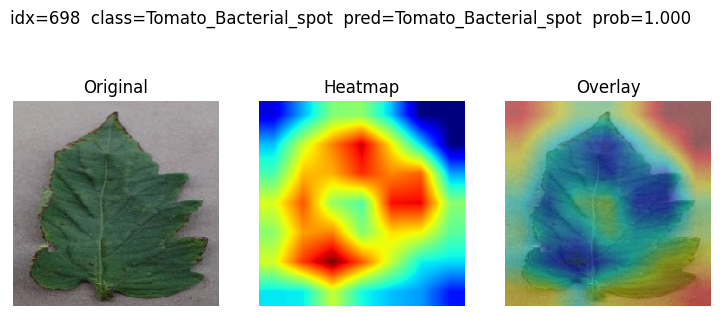

Saved: /content/output/gradcam/gradcam_idx698_Tomato_Bacterial_spot_heat.png and /content/output/gradcam/gradcam_idx698_Tomato_Bacterial_spot_overlay.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


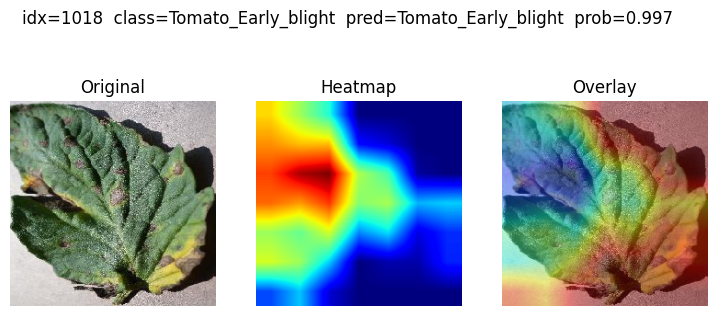

Saved: /content/output/gradcam/gradcam_idx1018_Tomato_Early_blight_heat.png and /content/output/gradcam/gradcam_idx1018_Tomato_Early_blight_overlay.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


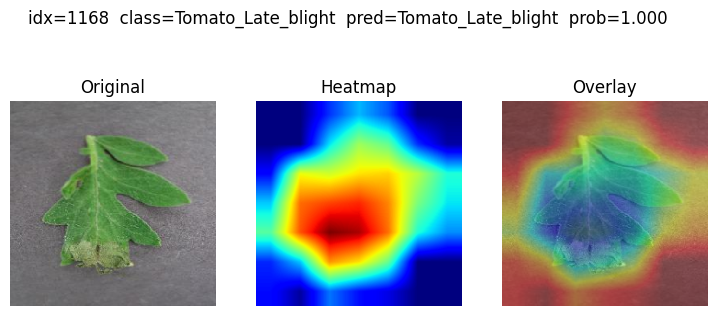

Saved: /content/output/gradcam/gradcam_idx1168_Tomato_Late_blight_heat.png and /content/output/gradcam/gradcam_idx1168_Tomato_Late_blight_overlay.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


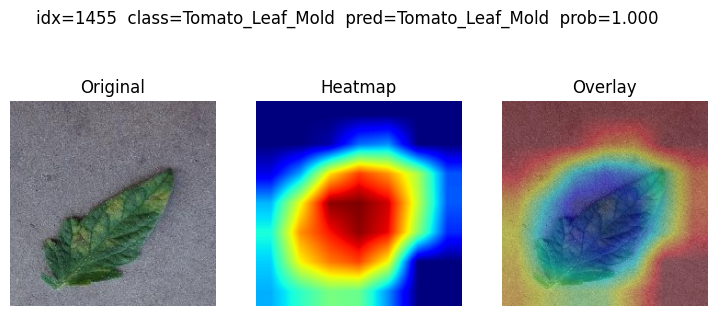

Saved: /content/output/gradcam/gradcam_idx1455_Tomato_Leaf_Mold_heat.png and /content/output/gradcam/gradcam_idx1455_Tomato_Leaf_Mold_overlay.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


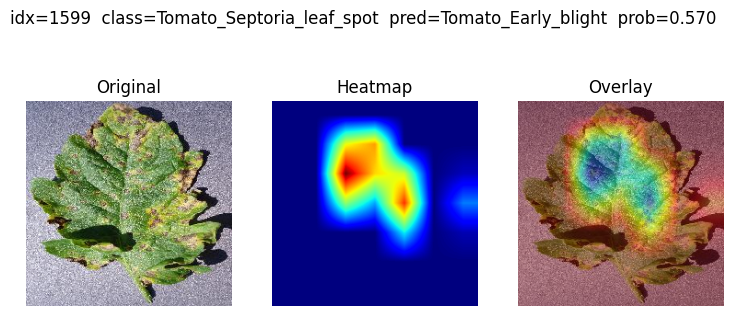

Saved: /content/output/gradcam/gradcam_idx1599_Tomato_Septoria_leaf_spot_heat.png and /content/output/gradcam/gradcam_idx1599_Tomato_Septoria_leaf_spot_overlay.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


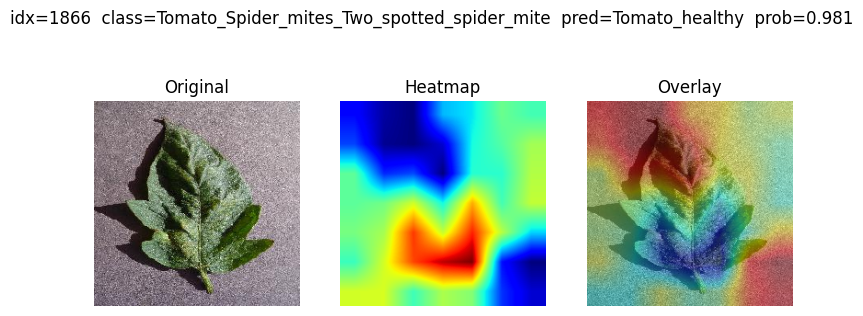

Saved: /content/output/gradcam/gradcam_idx1866_Tomato_Spider_mites_Two_spotted_spider_mite_heat.png and /content/output/gradcam/gradcam_idx1866_Tomato_Spider_mites_Two_spotted_spider_mite_overlay.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


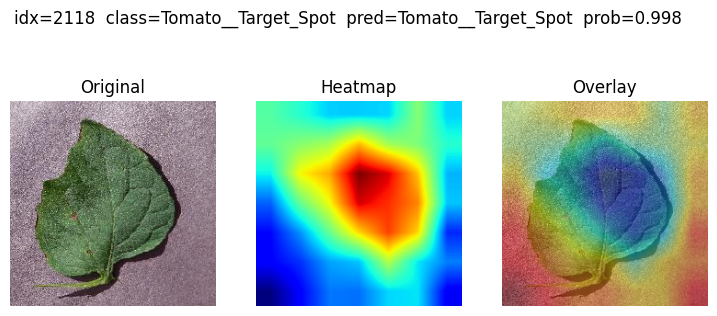

Saved: /content/output/gradcam/gradcam_idx2118_Tomato__Target_Spot_heat.png and /content/output/gradcam/gradcam_idx2118_Tomato__Target_Spot_overlay.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


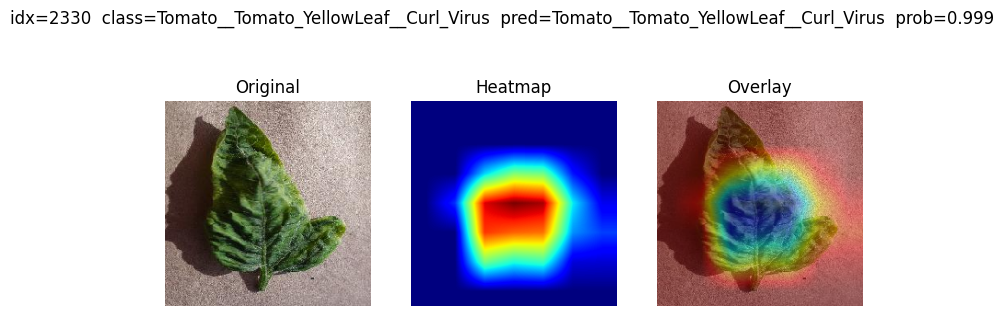

Saved: /content/output/gradcam/gradcam_idx2330_Tomato__Tomato_YellowLeaf__Curl_Virus_heat.png and /content/output/gradcam/gradcam_idx2330_Tomato__Tomato_YellowLeaf__Curl_Virus_overlay.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


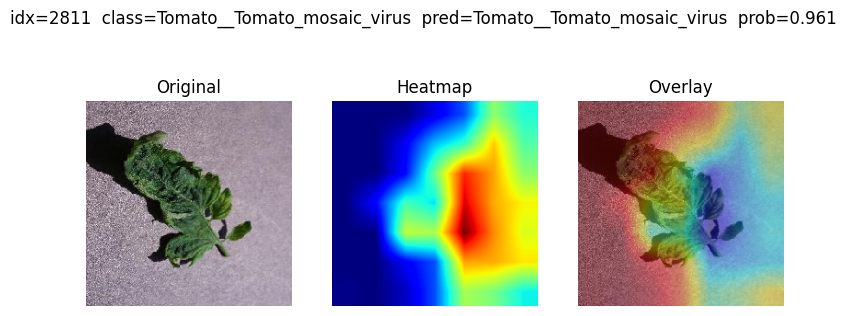

Saved: /content/output/gradcam/gradcam_idx2811_Tomato__Tomato_mosaic_virus_heat.png and /content/output/gradcam/gradcam_idx2811_Tomato__Tomato_mosaic_virus_overlay.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


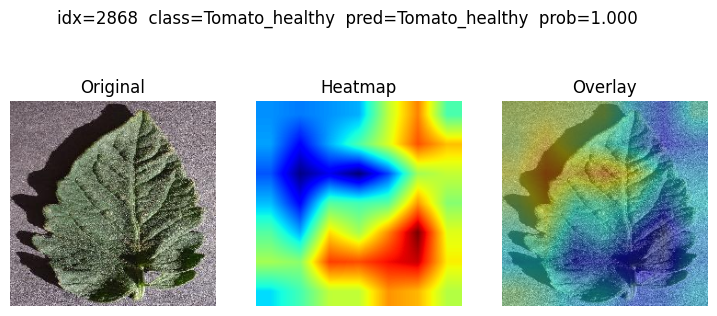

Saved: /content/output/gradcam/gradcam_idx2868_Tomato_healthy_heat.png and /content/output/gradcam/gradcam_idx2868_Tomato_healthy_overlay.png
Done — Grad-CAM images saved to /content/output/gradcam and copied to /content/drive/MyDrive/Colab Notebooks/plant_checkpoints


In [15]:
# ---------- Grad-CAM: one image per class (full ready-to-run cell) ----------
import os, numpy as np, matplotlib.pyplot as plt, shutil, itertools
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import cv2

# output dirs
LOCAL_OUT = "/content/output"
GRAD_OUT = os.path.join(LOCAL_OUT, "gradcam")
DRIVE_OUT = "/content/drive/MyDrive/Colab Notebooks/plant_checkpoints"
os.makedirs(GRAD_OUT, exist_ok=True)
os.makedirs(DRIVE_OUT, exist_ok=True)

# ---------- helpers ----------
def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.Model):
            for inner in reversed(layer.layers):
                if isinstance(inner, tf.keras.layers.Conv2D):
                    return inner.name
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in model")

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(inputs=model.inputs,
                                       outputs=[model.get_layer(last_conv_layer_name).output, model.output])
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        conv_outputs, predictions = grad_model(img_tensor)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    if grads is None:
        raise RuntimeError("Gradients are None — check the model.")
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))         # (channels,)
    conv_outputs = conv_outputs[0]                             # (H, W, C)
    weighted = conv_outputs * pooled_grads[tf.newaxis, tf.newaxis, :]
    heatmap = tf.reduce_sum(weighted, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    if max_val == 0:
        return np.zeros((heatmap.shape[0], heatmap.shape[1]))
    heatmap = heatmap / (max_val + 1e-8)
    return heatmap.numpy()

def load_test_image_by_index(gen, idx):
    if hasattr(gen, "filepaths"):
        fp = gen.filepaths[idx]
        img = image.load_img(fp, target_size=(gen.image_shape[0], gen.image_shape[1]))
        arr = image.img_to_array(img) / 255.0
        return img, arr, fp
    else:
        i = 0
        for batch_x, batch_y in gen:
            for b in range(len(batch_x)):
                if i == idx:
                    arr = batch_x[b]
                    return image.array_to_img(arr), arr, None
                i += 1
        raise IndexError("Index out of range for generator")

# ---------- select one index per class ----------
if not hasattr(test_gen, "filepaths") or not hasattr(test_gen, "classes"):
    raise RuntimeError("test_gen must be an ImageDataGenerator.flow_from_directory output with .filepaths and .classes")

labels = list(test_gen.class_indices.keys())
print("Detected classes:", len(labels))

# Build mapping from class_name -> first index encountered
class_to_idx = {}
for idx, cls_id in enumerate(test_gen.classes):
    cls_name = labels[cls_id]
    if cls_name not in class_to_idx:
        class_to_idx[cls_name] = idx

# Sort classes for consistent order
selected_classes = sorted(class_to_idx.keys())
indices = [class_to_idx[c] for c in selected_classes]
print(f"Selected {len(indices)} indices (one per class).")

# ---------- find last conv layer ----------
last_conv_name = find_last_conv_layer(model)
print("Using last conv layer:", last_conv_name)

# ---------- run Grad-CAM for each selected index ----------
for idx, cls_name in zip(indices, selected_classes):
    try:
        pil_img, img_arr, path = load_test_image_by_index(test_gen, idx)
    except Exception as e:
        print("Failed to load index", idx, ":", e)
        continue

    input_arr = np.expand_dims(img_arr, axis=0).astype(np.float32)
    preds = model.predict(input_arr)
    pred_idx = int(np.argmax(preds[0]))
    pred_label = labels[pred_idx]
    true_idx = int(test_gen.classes[idx])
    true_label = labels[true_idx]

    # Grad-CAM heatmap
    try:
        heatmap = make_gradcam_heatmap(input_arr, model, last_conv_name, pred_index=pred_idx)
    except Exception as e:
        print("Grad-CAM failed for idx", idx, ":", e)
        continue

    # resize + colorize
    heatmap_resized = cv2.resize(heatmap, (img_arr.shape[1], img_arr.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    orig_uint8 = np.uint8(255 * img_arr)
    overlay = cv2.addWeighted(orig_uint8, 0.6, colored, 0.4, 0)

    basefn = f"gradcam_idx{idx}_{cls_name}"
    heat_path = os.path.join(GRAD_OUT, basefn + "_heat.png")
    overlay_path = os.path.join(GRAD_OUT, basefn + "_overlay.png")

    # cv2.imwrite expects BGR ordering for colored images
    cv2.imwrite(heat_path, colored)
    cv2.imwrite(overlay_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

    # display inline
    plt.figure(figsize=(9,4))
    plt.suptitle(f"idx={idx}  class={cls_name}  pred={pred_label}  prob={preds[0][pred_idx]:.3f}")
    plt.subplot(1,3,1); plt.imshow(pil_img); plt.title("Original"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(heatmap_resized, cmap="jet"); plt.title("Heatmap"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(overlay); plt.title("Overlay"); plt.axis("off")
    plt.show()

    print("Saved:", heat_path, "and", overlay_path)

# ---------- copy all gradcam files to Drive ----------
for f in os.listdir(GRAD_OUT):
    try:
        shutil.copy(os.path.join(GRAD_OUT, f), DRIVE_OUT)
    except Exception as e:
        print("Copy to Drive failed for", f, ":", e)

print("Done — Grad-CAM images saved to", GRAD_OUT, "and copied to", DRIVE_OUT)


In [16]:
!pip install lime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=aac7b1f78c721d1d8fa96ff2dc30428ec4d20c99ebd89d7398d217a2f16f35bd
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [8]:

# ---------- select one index per class (one sample per class) ----------
labels = list(test_gen.class_indices.keys())
print("Detected classes:", len(labels))
print(labels)

class_to_idx = {cls: None for cls in labels}

# Fill dictionary with first index of each class
for idx, cls_id in enumerate(test_gen.classes):
    cls_name = labels[cls_id]
    if class_to_idx[cls_name] is None:
        class_to_idx[cls_name] = idx

print("\nSelected one sample per class:")
for cls in labels:
    print(cls, "-> idx", class_to_idx[cls])

indices = [class_to_idx[c] for c in labels]
print("\nFinal indices:", indices)


Detected classes: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']

Selected one sample per class:
Pepper__bell___Bacterial_spot -> idx 0
Pepper__bell___healthy -> idx 151
Potato___Early_blight -> idx 374
Potato___Late_blight -> idx 524
Potato___healthy -> idx 674
Tomato_Bacterial_spot -> idx 698
Tomato_Early_blight -> idx 1018
Tomato_Late_blight -> idx 1168
Tomato_Leaf_Mold -> idx 1455
Tomato_Septoria_leaf_spot -> idx 1599
Tomato_Spider_mites_Two_spotted_spider_mite -> idx 1866
Tomato__Target_Spot -> idx 2118
Tomato__Tomato_YellowLeaf__Curl_Virus -> idx 2330
Tomato__Tomato_mosaic_virus -> idx 2811
Tomato_healthy -> idx 2868

Fina

  0%|          | 0/1500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 649ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 861ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 609ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/

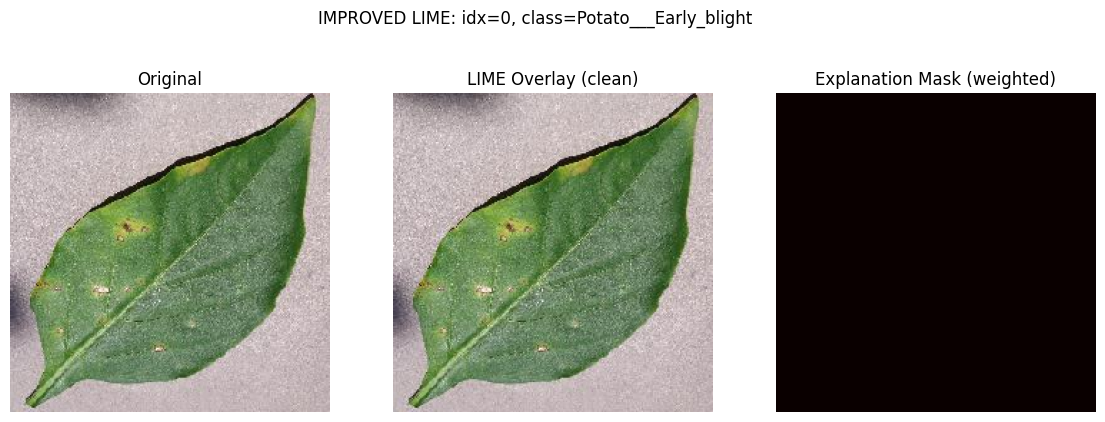

Saved LIME explanation for: /content/PlantVillage_split/test/Pepper__bell___Bacterial_spot/02baf62e-11e2-4dde-97fb-e369b57d55d3___JR_B.Spot 8971.JPG


  0%|          | 0/1500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 627ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 628ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 632ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 623ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

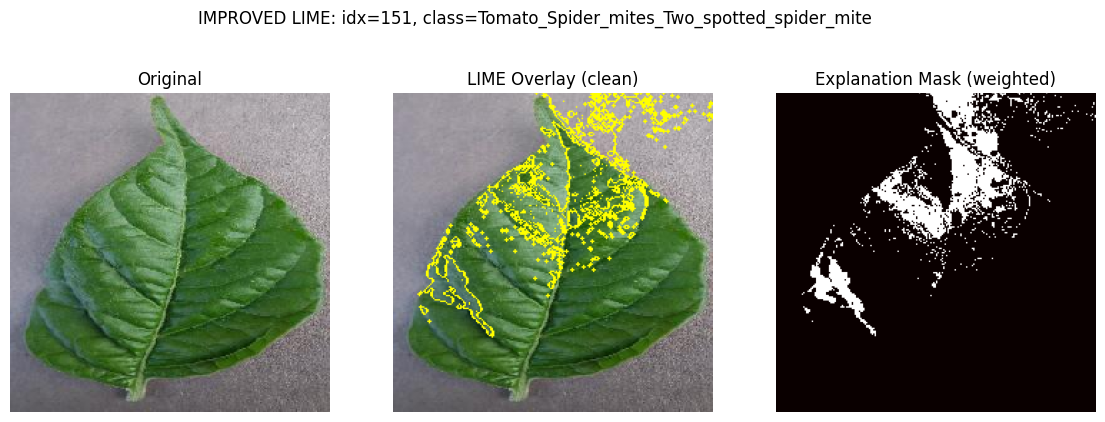

Saved LIME explanation for: /content/PlantVillage_split/test/Pepper__bell___healthy/00726ad4-2569-46ce-9d4e-dbf82b14bd94___JR_HL 8686.JPG


  0%|          | 0/1500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 624ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 598ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

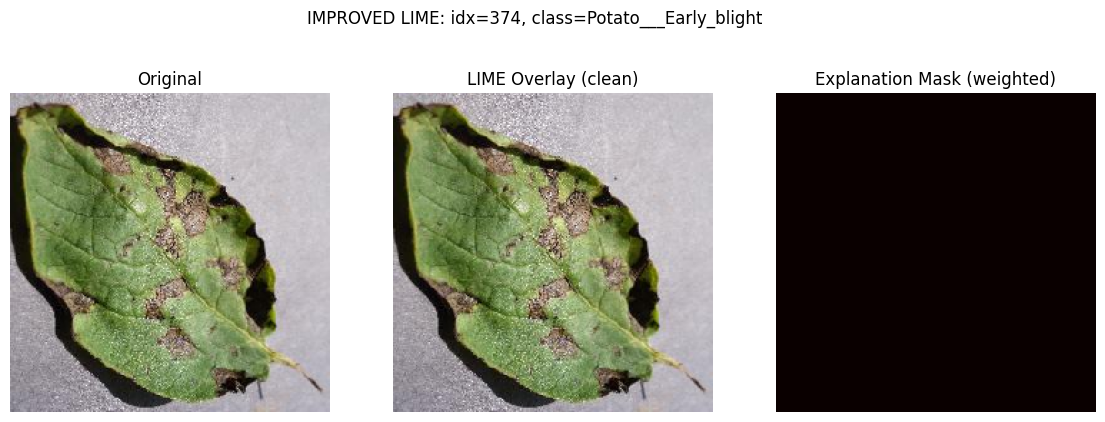

Saved LIME explanation for: /content/PlantVillage_split/test/Potato___Early_blight/002a55fb-7a3d-4a3a-aca8-ce2d5ebc6925___RS_Early.B 8170.JPG


  0%|          | 0/1500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 569ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 639ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 659ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 647ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

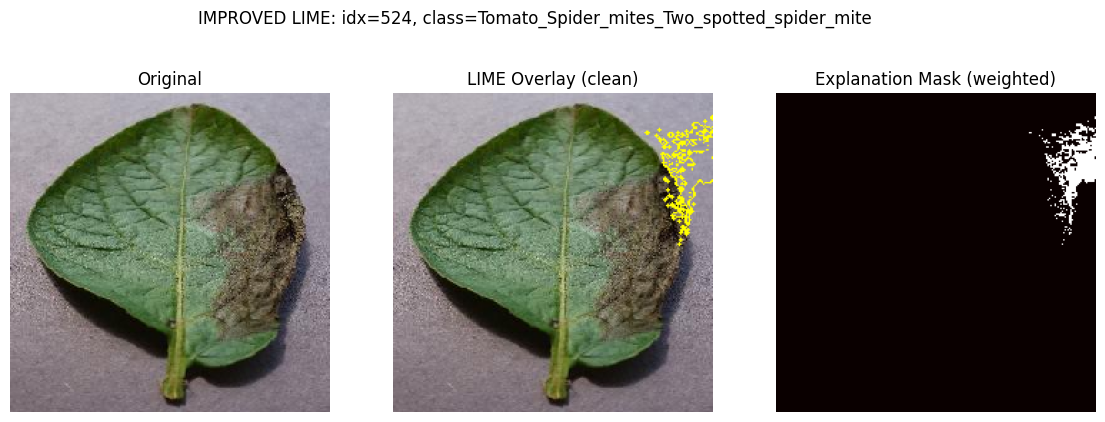

Saved LIME explanation for: /content/PlantVillage_split/test/Potato___Late_blight/01a8cc9f-074a-4866-87c8-bb5a9e3895b4___RS_LB 2968.JPG


  0%|          | 0/1500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 626ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 636ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

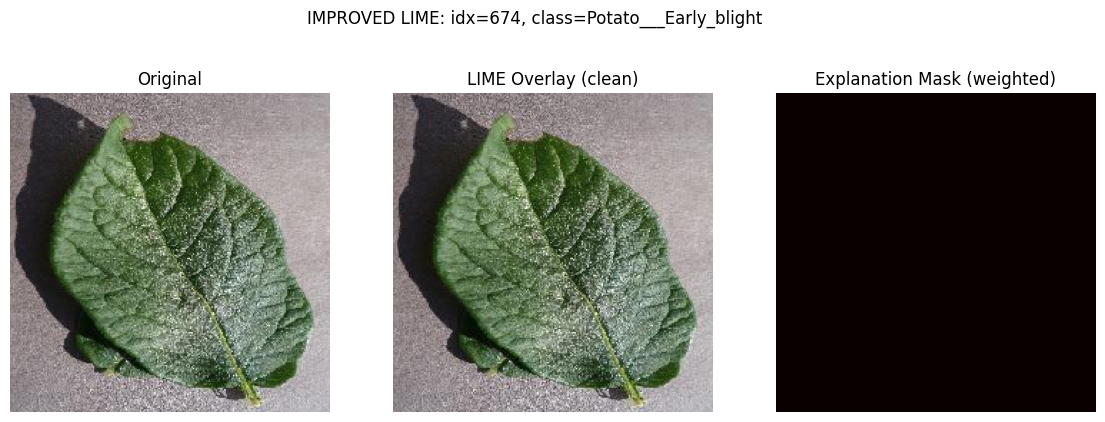

Saved LIME explanation for: /content/PlantVillage_split/test/Potato___healthy/142fb983-2166-4a0f-b99b-a6c21e99987e___RS_HL 5398.JPG


In [11]:
# ---------- IMPROVED LIME FOR CLEARER VISUALIZATION ----------
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
from tensorflow.keras.preprocessing import image

explainer = lime_image.LimeImageExplainer()

# Choose how many samples to explain
N_LIME = 5
lime_indices = indices[:N_LIME]   # use your per-class Grad-CAM indices

def load_img_for_lime(gen, idx):
    fp = gen.filepaths[idx]
    img = image.load_img(fp, target_size=(224,224))
    arr = image.img_to_array(img)
    return img, arr, fp

def predict_fn(imgs):
    imgs = np.array(imgs).astype(np.float32) / 255.0
    return model.predict(imgs)

for idx in lime_indices:
    pil_img, arr, path = load_img_for_lime(test_gen, idx)

    explanation = explainer.explain_instance(
        arr.astype(np.double),
        classifier_fn=predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=1500,         # more samples = smoother & clearer LIME
        segmentation_fn=None      # default segmentation
    )

    top_label = explanation.top_labels[0]

    # Improved mask extraction
    temp, mask = explanation.get_image_and_mask(
        top_label,
        positive_only=True,       # only what contributes to the class
        num_features=20,          # highlight more superpixels
        hide_rest=False,
        min_weight=0.02           # remove very tiny noisy ones
    )

    # Clean overlay for LIME
    lime_overlay = mark_boundaries(arr/255.0, mask)

    # Plot improved output
    plt.figure(figsize=(14,5))
    plt.suptitle(f"IMPROVED LIME: idx={idx}, class={labels[top_label]}")

    plt.subplot(1,3,1)
    plt.imshow(pil_img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(lime_overlay)
    plt.title("LIME Overlay (clean)")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(mask, cmap="hot")
    plt.title("Explanation Mask (weighted)")
    plt.axis("off")

    plt.show()

    print("Saved LIME explanation for:", path)
